In [1]:
import uproot as up
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection
%matplotlib inline


In [2]:
file=up.open("/home/rice/Projects/DUNE_Opticks/Build_Test/work/100k_17-3Voxel_Comparison.root")
#file=up.open("/home/rice/Projects/DUNE_Opticks/Build_Test/work/Photonlibrary_dune10kt_1x2x6_opticks_v6.root")
file.keys()

['generator;1',
 'generator/PhotonsGenerated;765',
 'generator/PhotonsGenerated;764',
 'largeant;1',
 'largeant/electronsPerStep;1',
 'largeant/photonsPerStep;1',
 'largeant/energyPerStep;1',
 'largeant/stepSize;1',
 'largeant/electronsPerLength;1',
 'largeant/photonsPerLength;1',
 'largeant/electronsPerEDep;1',
 'largeant/photonsPerEDep;1',
 'largeant/electronsVsPhotons;1',
 'opticks;1',
 'opticks/photon_gen;1184',
 'opticks/photon_gen;1183',
 'opticks/OpticksHits;34',
 'opticks/OpticksHits;33',
 'opticks/Visibilities;1',
 'pmtresponse;1',
 'pmtresponse/AllPhotons;1',
 'pmtresponse/DetectedPhotons;1',
 'pmtresponse/OpDets;1',
 'pmtresponse/OpDetEvents;1',
 'pmtresponse/PhotonLibraryData;1',
 'pmtresponse/NVoxels;1',
 'pmtresponse/NChannels;1',
 'pmtresponse/MinX;1',
 'pmtresponse/MinY;1',
 'pmtresponse/MinZ;1',
 'pmtresponse/MaxX;1',
 'pmtresponse/MaxY;1',
 'pmtresponse/MaxZ;1',
 'pmtresponse/StepX;1',
 'pmtresponse/StepY;1',
 'pmtresponse/StepZ;1',
 'pmtresponse/NDivX;1',
 'pmtrespon

In [3]:

file["pmtresponse/DetectedPhotons"].keys()

['EventID', 'Wavelength', 'OpChannel', 'Time']

In [4]:
G4Time=file["pmtresponse/DetectedPhotons/Time"].array().to_numpy()
G4Timev2=file["pmtresponse/OpDets/Time"].array().to_numpy()
G4Wavelength=file["pmtresponse/DetectedPhotons/Wavelength"].array().to_numpy()

In [5]:

G4=file["pmtresponse/PhotonLibraryData"]
print(G4.keys())

G4Voxel=G4["Voxel"].array().to_numpy()
G4SensorID=G4["OpChannel"].array().to_numpy()
G4Visibility=G4["Visibility"].array().to_numpy()

['Voxel', 'OpChannel', 'Visibility']


In [6]:

#f=up.open("/home/rice/Projects/DUNE_Opticks/OlderG4OpticksGDML/dune10kt_v5_refactored_1x2x6_e_3GeV.root")
O=file["opticks/Visibilities"]
print(O.keys())
OVoxel=O["Voxel"].array().to_numpy()
OSensorID=O["OptDetID"].array().to_numpy()
OVisibility=O["Visibility"].array().to_numpy()
OhitSensID=file["opticks/OpticksHits/sensor_id"].array().to_numpy()

['Voxel', 'OptDetID', 'Visibility']


In [7]:
print(len(G4Voxel))
print(len(OVoxel))
print(1-len(G4Voxel)/len(OVoxel))


1205256
1150660
-0.04744755183981364


Text(0.5, 0, 'Visibilities')

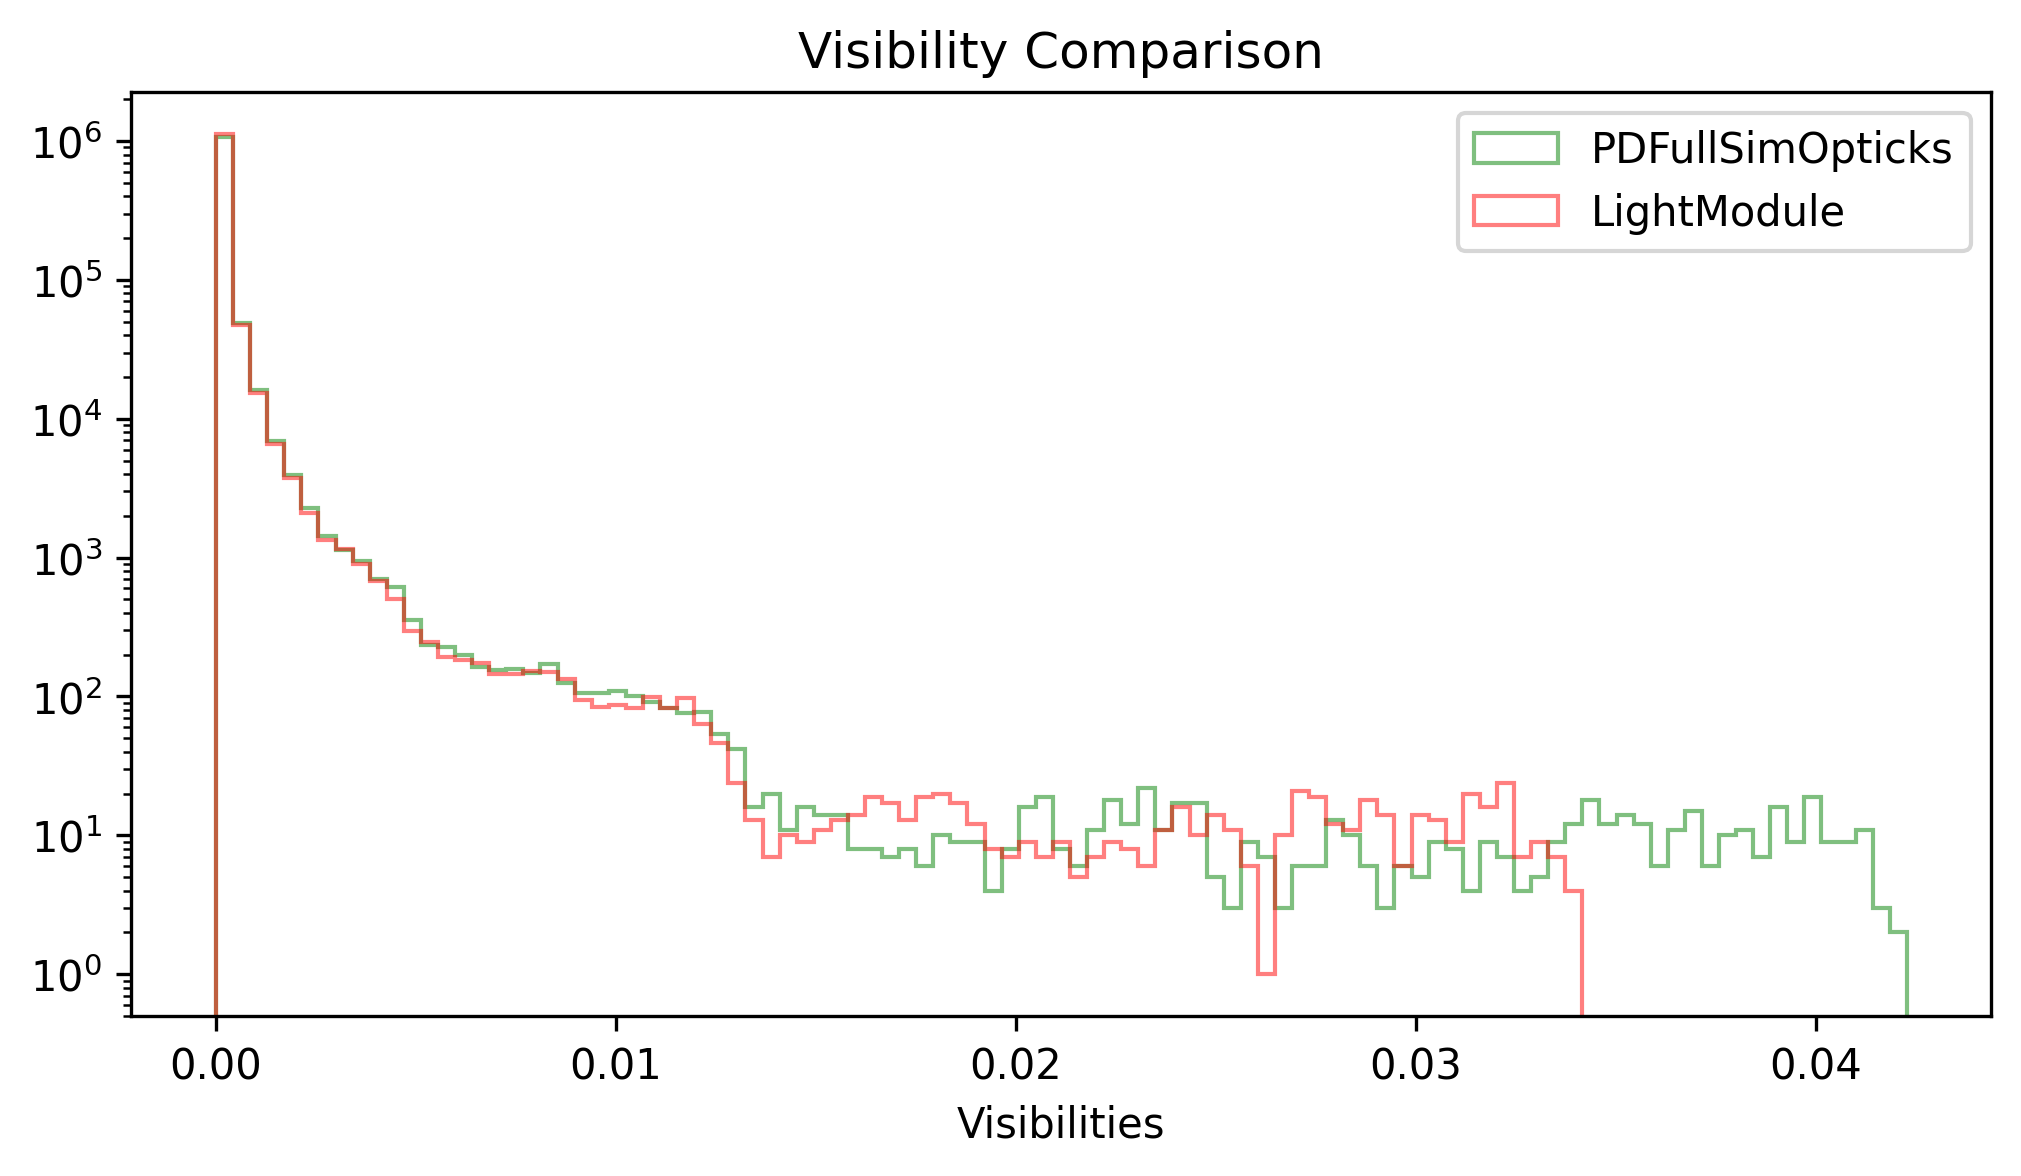

In [8]:
vismin = min(OVisibility.min(), G4Visibility.min())
vismax = max(OVisibility.max(), G4Visibility.max())
xbins = np.linspace(vismin , vismax , 100)

plt.figure(figsize=(8,4),dpi=300)
plt.title("Visibility Comparison")
h1=plt.hist(OVisibility, bins=xbins, alpha=0.5, label="PDFullSimOpticks",histtype="step",color="green")
h2=plt.hist(G4Visibility, bins=xbins, alpha=0.5, label="LightModule",histtype="step",color="red")
plt.legend()
#plt.loglog()
plt.semilogy()
plt.xlabel("Visibilities")

In [9]:
result=h2[0]/h1[0]

[]

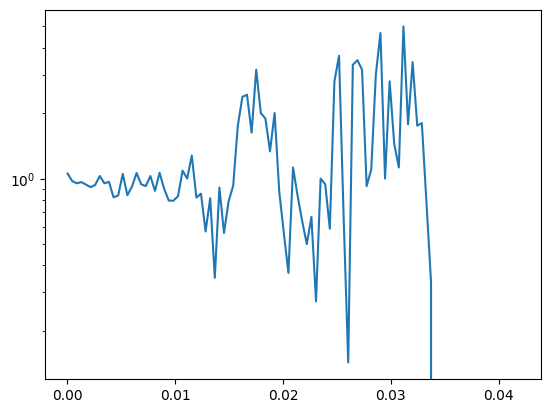

In [10]:
plt.plot(h2[1][:-1],result)
plt.semilogy()

Text(0.5, 0, 'Arapuca ID')

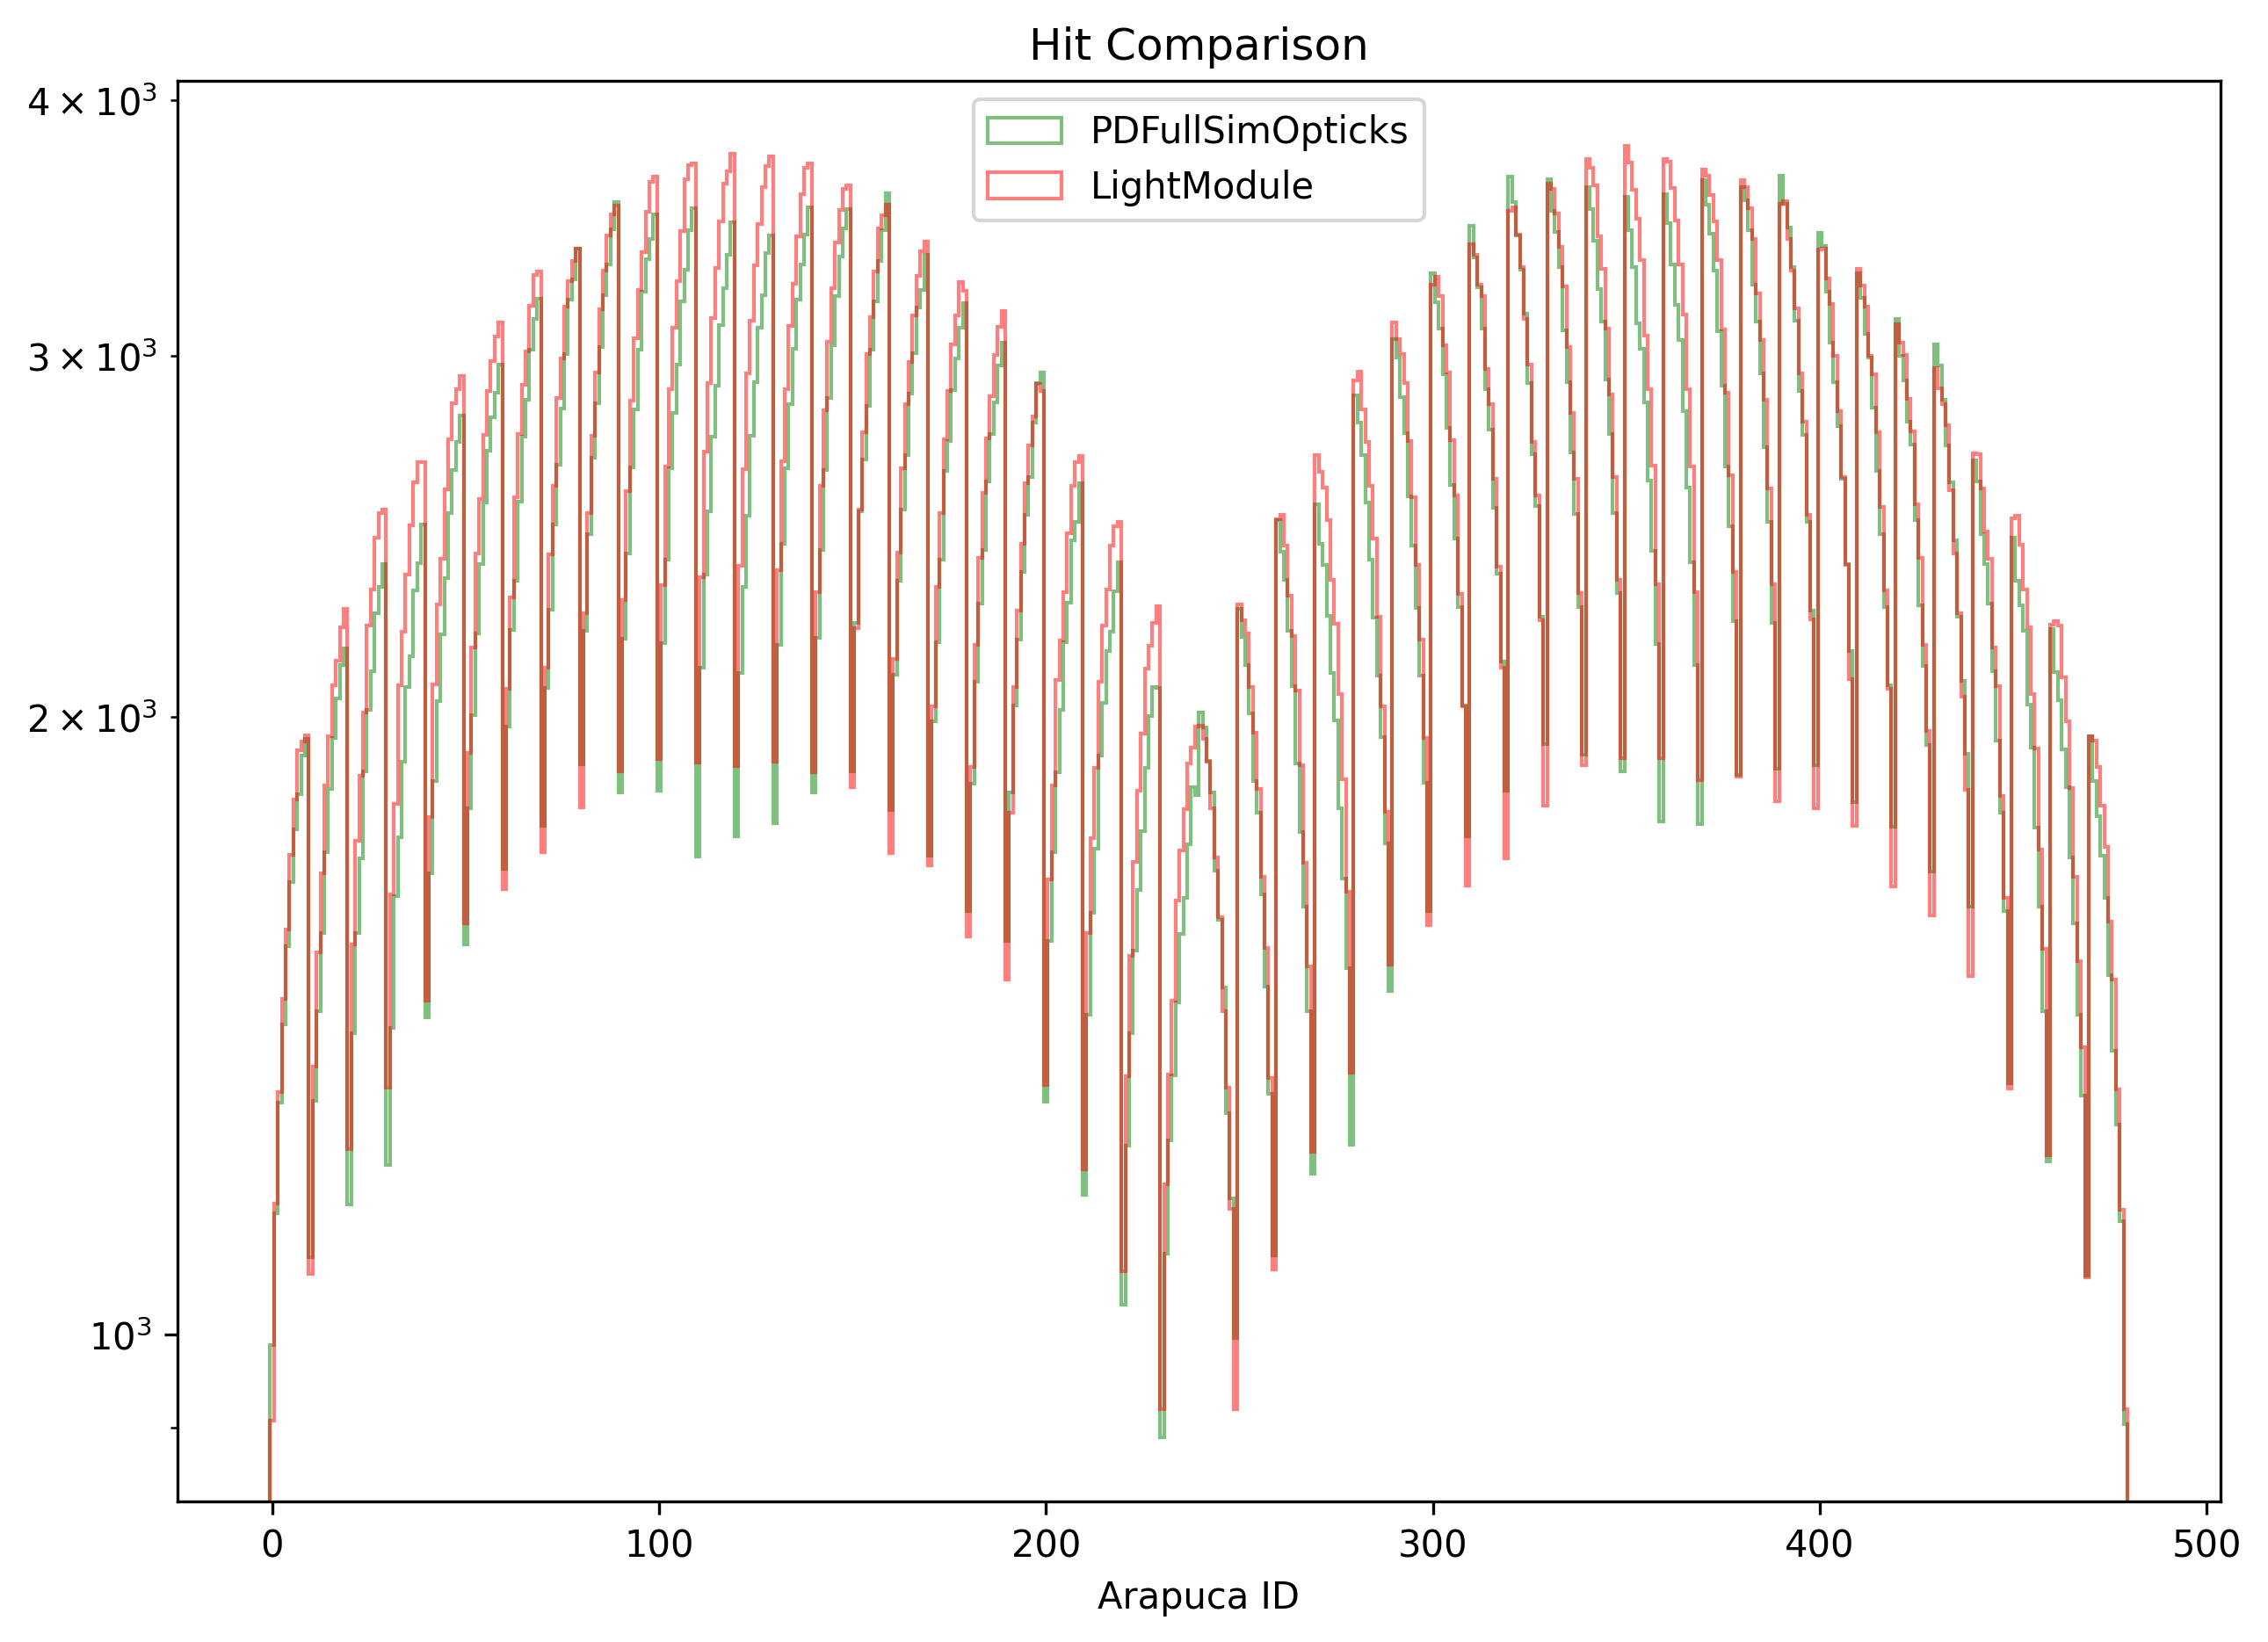

In [11]:
vismin = min(OSensorID.min(), G4SensorID.min())
vismax = max(OSensorID.max(), G4SensorID.max())
xbins = np.arange(vismin-0.5 , vismax+1.5 , 1)
plt.figure(figsize=(10,7),dpi=300)
plt.title("Hit Comparison")
plt.hist(OSensorID, bins=xbins, alpha=0.5, label="PDFullSimOpticks",histtype="step",color="green")
plt.hist(G4SensorID, bins=xbins, alpha=0.5, label="LightModule",histtype="step",color="red")
#plt.hist(OhitSensID, bins=xbins, alpha=0.5, label="Optickshits")
plt.legend()
plt.semilogy()
plt.xlabel("Arapuca ID")


In [12]:
ox=file["opticks/OpticksHits/x"].array().to_numpy()
oy=file["opticks/OpticksHits/y"].array().to_numpy()
oz=file["opticks/OpticksHits/z"].array().to_numpy()
ot=file["opticks/OpticksHits/t"].array().to_numpy()

osid=file["opticks/OpticksHits/sensor_id"].array().to_numpy()
owavelength=file["opticks/OpticksHits/wavelength"].array().to_numpy()

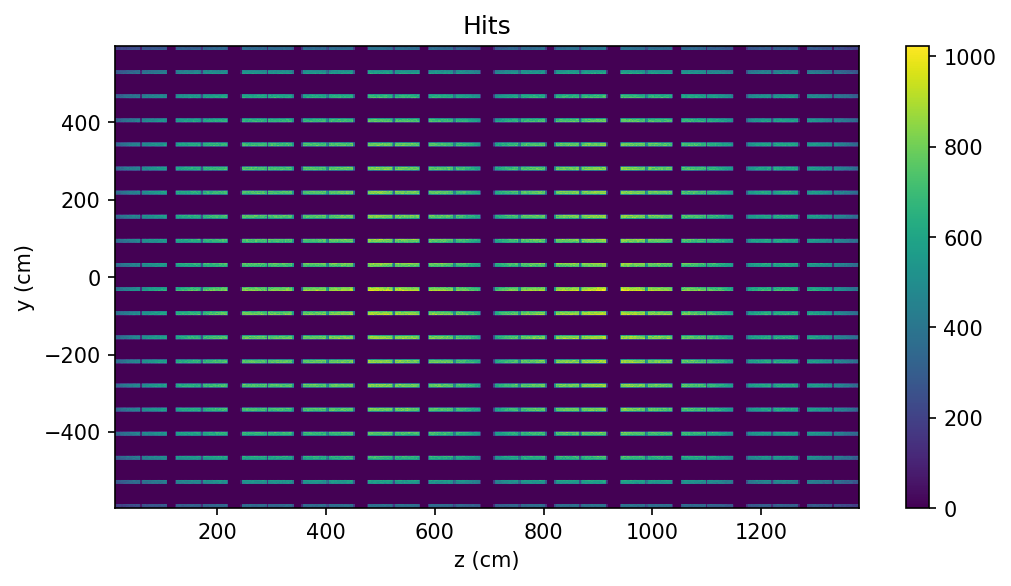

In [13]:
plt.figure(figsize=(8,4),dpi=150)
plt.title("Hits")
_=plt.hist2d(oz/10,oy/10,bins=500,cmin=0,cmax=2000)
plt.xlabel("z (cm)")
plt.ylabel("y (cm)")
plt.colorbar();

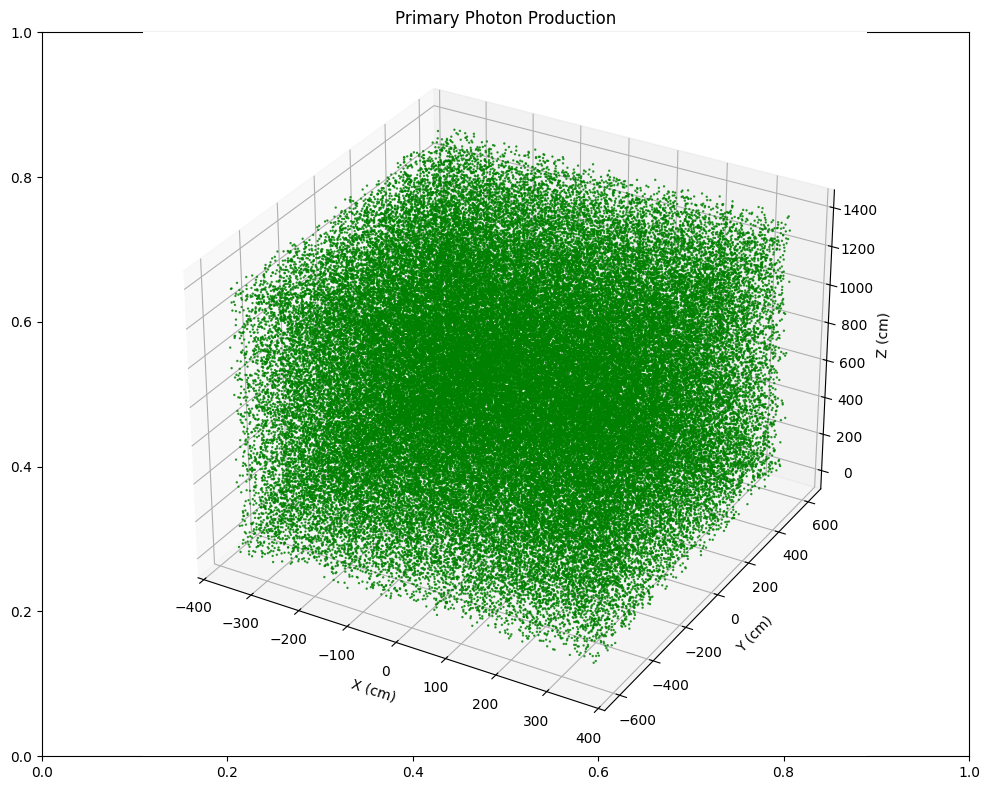

In [14]:

initPhotons=file["generator/PhotonsGenerated"]
# load and flatten arrays
x = np.asarray(initPhotons["X"].array(library="np")).ravel()
y = np.asarray(initPhotons["Y"].array(library="np")).ravel()
z = np.asarray(initPhotons["Z"].array(library="np")).ravel()

# mask and downsample
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
pts = np.vstack((x[mask], y[mask], z[mask])).T
N = 100000  # keep this <= 100k for reasonable speed
if pts.shape[0] > N:
    idx = np.random.choice(pts.shape[0], N, replace=False)
    pts = pts[idx]

fig = plt.figure(figsize=(10,8))
plt.title("Primary Photon Production")
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=0.5, color="green", alpha=0.8)
ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)'); ax.set_zlabel('Z (cm)')
#plt.colorbar(sc, label='Z')
plt.tight_layout()
plt.savefig('cloud_3d.png', dpi=200)  # offscreen-friendly
plt.show()


In [15]:
G4Time

array([289., 219.,  82., ..., 128., 143., 100.],
      shape=(19443119,), dtype=float32)

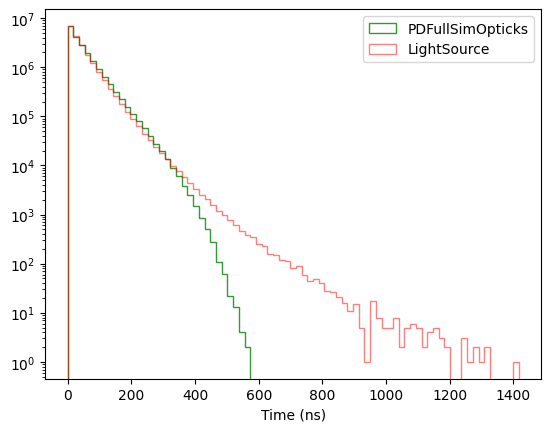

In [16]:
vismin = min(ot.min(), G4Time.min())
vismax = max(ot.max(), G4Time.max())
xbins = np.linspace(vismin , vismax , 80)
plt.hist(ot,color="green", bins=xbins, alpha=0.8,label="PDFullSimOpticks",histtype="step")
plt.hist(G4Time,color="red", bins=xbins,alpha=0.5,label="LightSource",histtype="step")
plt.xlabel("Time (ns)")
plt.semilogy()
plt.legend()
plt.show()